# Visuelle 2.0 EDA

**Owner:** Nilakshi  
**Module:** CCS4310 – Deep Learning  

This notebook inspects the locally available Visuelle files and identifies a defensible time-aware demand target without fabricating columns or results.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
plt.style.use('default')

In [2]:
def find_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / 'data' / 'raw' / 'visuelle').is_dir(): return p
    raise FileNotFoundError('Could not locate data/raw/visuelle.')
ROOT = find_root(); DATA_DIR = ROOT / 'data' / 'raw' / 'visuelle'
FIG_DIR = ROOT / 'outputs' / 'figures'; FIG_DIR.mkdir(parents=True, exist_ok=True)
assert DATA_DIR.is_dir()
print('Repository:', ROOT)
print('Shared project kernel only; no notebook-local environment or installs are used.')

Repository: d:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI
Shared project kernel only; no notebook-local environment or installs are used.


## File inventory

In [3]:
inventory=[]
for p in sorted(DATA_DIR.rglob('*')):
    if p.is_file():
        inventory.append({'path':str(p.relative_to(DATA_DIR)), 'file_type':p.suffix.lower() or 'none', 'size_mb':round(p.stat().st_size/1024**2,3)})
inventory_df=pd.DataFrame(inventory)
display(inventory_df)
print('Resource types:', inventory_df['file_type'].value_counts().to_dict())
for name in ['sales.csv','price_discount_series.csv','restocks.csv','stfore_train.csv','stfore_test.csv','vis2_gtrends_data.csv','vis2_weather_data.csv']:
    path=DATA_DIR/name
    print(name, 'exists=',path.is_file(), 'size_mb=',round(path.stat().st_size/1024**2,3) if path.is_file() else None)
for name in ['category_labels.pt','color_labels.pt','fabric_labels.pt']:
    path=DATA_DIR/name
    if path.is_file():
        try:
            import torch
            obj=torch.load(path,map_location='cpu',weights_only=False)
            print(name, 'mapping keys=',list(obj)[:10] if isinstance(obj,dict) else type(obj).__name__)
        except Exception as exc: print(name, 'not loaded:',type(exc).__name__,exc)

,path,file_type,size_mb
0,category_labels.pt,.pt,0.001
1,color_labels.pt,.pt,0.001
2,customer_data.csv,.csv,110.988
3,fabric_labels.pt,.pt,0.001
4,images\AI17\00955.png,.png,0.101
...,...,...,...
5364,stfore_sales_norm_scalar.npy,.npy,0.000
5365,stfore_test.csv,.csv,2.469
5366,stfore_train.csv,.csv,22.515
5367,vis2_gtrends_data.csv,.csv,0.075


Resource types: {'.png': 5355, '.csv': 8, '.pt': 4, '.md': 1, '.npy': 1}
sales.csv exists= True size_mb= 12.462
price_discount_series.csv exists= True size_mb= 7.708
restocks.csv exists= True size_mb= 16.064
stfore_train.csv exists= True size_mb= 22.515
stfore_test.csv exists= True size_mb= 2.469
vis2_gtrends_data.csv exists= True size_mb= 0.075
vis2_weather_data.csv exists= True size_mb= 5.863
category_labels.pt mapping keys= ['culottes', 'shorts', 'drop sleeve', 'long sleeve', 'medium coat', 'miniskirt', 'sheath dress', 'sleeveless', 'short sleeves', 'long dress']
color_labels.pt mapping keys= ['grey', 'white', 'black', 'green', 'brown', 'red', 'yellow', 'blue', 'violet', 'orange']
fabric_labels.pt mapping keys= ['polyviscous', 'satin cotton', 'technical', 'crepe', 'cloth', 'devore', 'embossed', 'acrylic', 'georgette', 'nice']


## Safe tabular inspection

In [4]:
tables={}
for name in ['sales.csv','price_discount_series.csv','restocks.csv','stfore_train.csv','stfore_test.csv','vis2_gtrends_data.csv','vis2_weather_data.csv']:
    path=DATA_DIR/name
    if not path.is_file():
        print(name,'missing; skipped'); continue
    try:
        sample=pd.read_csv(path,nrows=1000); tables[name]=sample
        full_shape=(sum(1 for _ in open(path,encoding='utf-8'))-1,len(sample.columns))
        print(f'\n=== {name} | approx shape {full_shape} ===')
        print('columns:',list(sample.columns)); print('dtypes:\n',sample.dtypes.to_string())
        print('missing in sample:',sample.isna().sum().sort_values(ascending=False).head(10).to_dict())
        print('duplicate sample rows:',int(sample.duplicated().sum()))
        display(sample.head(3))
    except Exception as exc: print(name,type(exc).__name__,exc)


=== sales.csv | approx shape (106850, 22) ===
columns: ['Unnamed: 0', 'external_code', 'retail', 'season', 'category', 'color', 'image_path', 'fabric', 'release_date', 'restock', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
dtypes:
 Unnamed: 0         int64
external_code      int64
retail             int64
season               str
category             str
color                str
image_path           str
fabric               str
release_date         str
restock            int64
0                float64
1                float64
2                float64
3                float64
4                float64
5                float64
6                float64
7                float64
8                float64
9                float64
10               float64
11               float64
missing in sample: {'Unnamed: 0': 0, 'external_code': 0, 'retail': 0, 'season': 0, 'category': 0, 'color': 0, 'image_path': 0, 'fabric': 0, 'release_date': 0, 'restock': 0}
duplicate sample rows: 0


,Unnamed: 0,external_code,retail,season,category,color,image_path,fabric,release_date,restock,...,2,3,4,5,6,7,8,9,10,11
0,0,5,36,SS17,long sleeve,grey,PE17/00005.png,acrylic,2016-11-28,22,...,1.0,1.0,2.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0
1,1,2,51,SS17,long sleeve,violet,PE17/00002.png,acrylic,2016-11-28,17,...,1.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0
2,2,5,10,SS17,long sleeve,grey,PE17/00005.png,acrylic,2016-11-28,15,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0



=== price_discount_series.csv | approx shape (106850, 15) ===
columns: ['external_code', 'retail', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', 'price']
dtypes:
 external_code      int64
retail             int64
0                float64
1                float64
2                float64
3                float64
4                float64
5                float64
6                float64
7                float64
8                float64
9                float64
10               float64
11               float64
price            float64
missing in sample: {'external_code': 0, 'retail': 0, '0': 0, '1': 0, '2': 0, '3': 0, '4': 0, '5': 0, '6': 0, '7': 0}
duplicate sample rows: 0


,external_code,retail,0,1,2,3,4,5,6,7,8,9,10,11,price
0,5,36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.054944
1,2,51,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0.054944
2,5,10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.054944



=== restocks.csv | approx shape (949766, 5) ===
columns: ['external_code', 'retail', 'week', 'year', 'qty']
dtypes:
 external_code    int64
retail           int64
week             int64
year             int64
qty              int64
missing in sample: {'external_code': 0, 'retail': 0, 'week': 0, 'year': 0, 'qty': 0}
duplicate sample rows: 0


...

,external_code,retail,season,category,color,image_path,fabric,release_date,restock,0,...,2,3,4,5,6,7,8,9,10,11
0,5198,100,SS19,culottes,grey,PE19/05198.png,linen,2019-05-06,0.320755,0.018868,...,0.018868,0.018868,0.037736,0.037736,0.018868,0.037736,0.056604,0.000000,0.000000,0.018868
1,5180,74,SS19,long dress,black,PE19/05180.png,tulle,2019-05-06,1.792453,0.113208,...,0.113208,0.113208,0.094340,0.169811,0.094340,0.056604,0.301887,0.283019,0.113208,0.000000
2,5159,43,SS19,culottes,white,PE19/05159.png,linen,2019-05-06,0.207547,0.018868,...,0.000000,0.018868,0.000000,0.018868,0.000000,0.037736,0.018868,0.018868,0.000000,0.000000



=== vis2_gtrends_data.csv | approx shape (220, 97) ===
columns: ['date', 'long sleeve', 'culottes', 'miniskirt', 'short sleeves', 'printed shirt', 'short cardigan', 'solid color top', 'trapeze dress', 'sleeveless', 'long cardigan', 'sheath dress', 'short coat', 'medium coat', 'doll dress', 'long dress', 'shorts', 'long coat', 'jumpsuit', 'drop sleeve', 'patterned top', 'kimono dress', 'medium cardigan', 'shirt dress', 'maxi', 'capris', 'gitana skirt', 'long duster', 'yellow', 'brown', 'blue', 'grey', 'green', 'black', 'red', 'white', 'orange', 'violet', 'acrylic', 'scuba crepe', 'tulle', 'angora', 'faux leather', 'georgette', 'lurex', 'nice', 'crepe', 'satin cotton', 'silky satin', 'fur', 'matte jersey', 'plisse', 'velvet', 'lace', 'cotton', 'piquet', 'plush', 'bengaline', 'jacquard', 'frise', 'technical', 'cady', 'dark jeans', 'light jeans', 'ity', 'plumetis', 'polyviscous', 'dainetto', 'webbing', 'foam rubber', 'chanel', 'marocain', 'macrame', 'embossed', 'heavy jeans', 'nylon', 'te

,date,long sleeve,culottes,miniskirt,short sleeves,printed shirt,short cardigan,solid color top,trapeze dress,sleeveless,...,scottish,milano stitch,devore,hron,ottoman,fluid,flamed,fluid polyviscous,shiny jersey,goose
0,2015-10-05,55.0,41.0,66.0,58.0,58.0,22.0,24.0,43.0,66.0,...,57,0,29,17,57,80,49,-1.0,0,34
1,2015-10-12,55.0,44.0,73.0,71.0,61.0,31.0,37.0,21.2,63.0,...,54,0,17,14,61,80,41,-1.0,0,39
2,2015-10-19,60.0,42.0,73.0,62.0,61.0,43.0,37.0,27.4,47.0,...,55,0,21,23,63,79,52,-1.0,33,41



=== vis2_weather_data.csv | approx shape (89071, 14) ===
columns: ['locality', 'date', 'avg temp °C', 'min temp °C', 'max temp °C', 'dew point °C', 'humidity %', 'visibility km', 'avg wind km/h', 'max wind km/h', 'gust km/h', 'slm pressure mb', 'avg pressure mb', 'rain mm']
dtypes:
 locality             int64
date                   str
avg temp °C        float64
min temp °C        float64
max temp °C        float64
dew point °C       float64
humidity %         float64
visibility km      float64
avg wind km/h      float64
max wind km/h      float64
gust km/h          float64
slm pressure mb    float64
avg pressure mb    float64
rain mm            float64
missing in sample: {'min temp °C': 2, 'avg temp °C': 2, 'max temp °C': 2, 'dew point °C': 2, 'visibility km': 2, 'humidity %': 2, 'gust km/h': 2, 'slm pressure mb': 2, 'avg wind km/h': 2, 'max wind km/h': 2}
duplicate sample rows: 0


,locality,date,avg temp °C,min temp °C,max temp °C,dew point °C,humidity %,visibility km,avg wind km/h,max wind km/h,gust km/h,slm pressure mb,avg pressure mb,rain mm
0,8,1/1/2016,6.0,2.0,11.0,2.0,69.0,10.0,9.0,13.0,0.0,1026.0,0.0,0.0
1,8,2/1/2016,9.0,2.0,14.0,5.0,69.0,10.0,11.0,17.0,0.0,1020.0,0.0,0.0
2,8,3/1/2016,12.0,8.0,15.0,10.0,86.0,9.0,12.0,22.0,52.0,1007.0,0.0,0.0


## Structure, missingness, and target discovery

In [5]:
sales_path=DATA_DIR/'sales.csv'; assert sales_path.is_file()
sales=pd.read_csv(sales_path)
weekly_cols=[c for c in sales.columns if str(c).isdigit()]
assert weekly_cols and 'release_date' in sales.columns
sales['release_date']=pd.to_datetime(sales['release_date'],errors='coerce')
print('sales shape:',sales.shape)
print('weekly lifecycle demand columns:',weekly_cols)
print('date range:',sales['release_date'].min(),'to',sales['release_date'].max())
print('identifier candidates:',[c for c in sales.columns if c in ['external_code','retail']])
print('categorical columns:',sales.select_dtypes(exclude=np.number).columns.tolist())
display(sales.head(3)); display(sales.dtypes.to_frame('dtype'))
display(sales.isna().sum().sort_values(ascending=False).head(20).to_frame('missing'))
print('duplicate rows:',int(sales.duplicated().sum()))
print('numeric statistics:'); display(sales.select_dtypes(include=np.number).describe().T[['count','mean','50%','std','min','max']].rename(columns={'50%':'median'}))
for c in sales.select_dtypes(exclude=np.number).columns:
    print(f'{c}: unique={sales[c].nunique(dropna=True)}, mode={sales[c].mode(dropna=True).iloc[0] if not sales[c].mode(dropna=True).empty else None}')

sales shape: (106850, 22)
weekly lifecycle demand columns: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
date range: 2016-11-28 00:00:00 to 2019-12-30 00:00:00
identifier candidates: ['external_code', 'retail']
categorical columns: ['season', 'category', 'color', 'image_path', 'fabric', 'release_date']


,Unnamed: 0,external_code,retail,season,category,color,image_path,fabric,release_date,restock,...,2,3,4,5,6,7,8,9,10,11
0,0,5,36,SS17,long sleeve,grey,PE17/00005.png,acrylic,2016-11-28,22,...,1.0,1.0,2.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0
1,1,2,51,SS17,long sleeve,violet,PE17/00002.png,acrylic,2016-11-28,17,...,1.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0
2,2,5,10,SS17,long sleeve,grey,PE17/00005.png,acrylic,2016-11-28,15,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0


,dtype
Unnamed: 0,int64
external_code,int64
retail,int64
season,str
category,str
color,str
image_path,str
fabric,str
release_date,datetime64[us]
restock,int64


,missing
Unnamed: 0,0
external_code,0
retail,0
season,0
category,0
color,0
image_path,0
fabric,0
release_date,0
restock,0


duplicate rows: 0
numeric statistics:


,count,mean,median,std,min,max
Unnamed: 0,106850.0,53424.500000,53424.5,30845.082469,0.0,106849.0
external_code,106850.0,3108.302134,3173.0,1593.085572,1.0,5577.0
retail,106850.0,41.349415,38.0,28.040672,0.0,125.0
restock,106850.0,22.436022,18.0,16.970656,1.0,389.0
0,106850.0,1.825372,1.0,1.252241,0.0,25.0
1,106850.0,1.500440,1.0,1.564483,0.0,27.0
2,106850.0,1.448030,1.0,1.577184,0.0,27.0
3,106850.0,1.456359,1.0,1.643756,0.0,27.0
4,106850.0,1.423828,1.0,1.680707,-2.0,43.0
5,106850.0,1.409911,1.0,1.758441,-3.0,34.0


season: unique=6, mode=AW19
category: unique=27, mode=culottes
color: unique=10, mode=black
image_path: unique=5355, mode=AI19/04656.png
fabric: unique=59, mode=georgette
release_date: unique=162, mode=2019-11-25 00:00:00


In [6]:
numeric_cols=sales.select_dtypes(include=np.number).columns.tolist()
print('Numerical descriptive statistics')
display(sales[numeric_cols].describe().T[['count','mean','50%','std','min','max']].rename(columns={'50%':'median'}))
for c in sales.select_dtypes(exclude=np.number).columns:
    print(f'{c}: unique={sales[c].nunique(dropna=True)}, mode={sales[c].mode(dropna=True).iloc[0] if not sales[c].mode(dropna=True).empty else None}')

Numerical descriptive statistics


,count,mean,median,std,min,max
Unnamed: 0,106850.0,53424.500000,53424.5,30845.082469,0.0,106849.0
external_code,106850.0,3108.302134,3173.0,1593.085572,1.0,5577.0
retail,106850.0,41.349415,38.0,28.040672,0.0,125.0
restock,106850.0,22.436022,18.0,16.970656,1.0,389.0
0,106850.0,1.825372,1.0,1.252241,0.0,25.0
1,106850.0,1.500440,1.0,1.564483,0.0,27.0
2,106850.0,1.448030,1.0,1.577184,0.0,27.0
3,106850.0,1.456359,1.0,1.643756,0.0,27.0
4,106850.0,1.423828,1.0,1.680707,-2.0,43.0
5,106850.0,1.409911,1.0,1.758441,-3.0,34.0


season: unique=6, mode=AW19
category: unique=27, mode=culottes
color: unique=10, mode=black
image_path: unique=5355, mode=AI19/04656.png
fabric: unique=59, mode=georgette
release_date: unique=162, mode=2019-11-25 00:00:00


## Time-aware demand view

Exact weekly price/discount matches: 1282199 of 1282200
Interpretation: sales columns 0-11 are weekly lifecycle observations; period_date = release_date + period_index weeks.
weekly period range: 2016-11-28 00:00:00 to 2020-03-16 00:00:00


,count,mean,sum
week_of_year,,,
1,28862,1.396126,40295.0
2,26644,1.194077,31815.0
3,24751,0.951719,23556.0
4,22347,0.856580,19142.0
5,20325,0.811316,16490.0
6,18383,0.885438,16277.0
7,16425,0.876286,14393.0
8,14329,0.940052,13470.0
9,13649,1.019196,13911.0


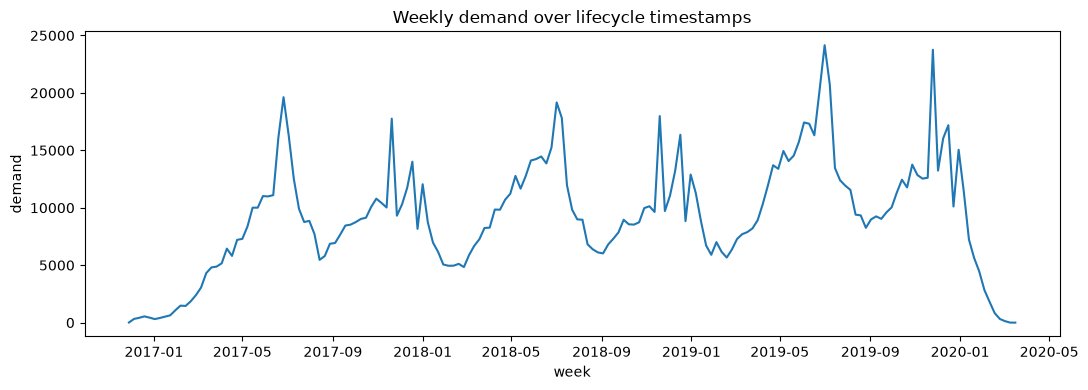

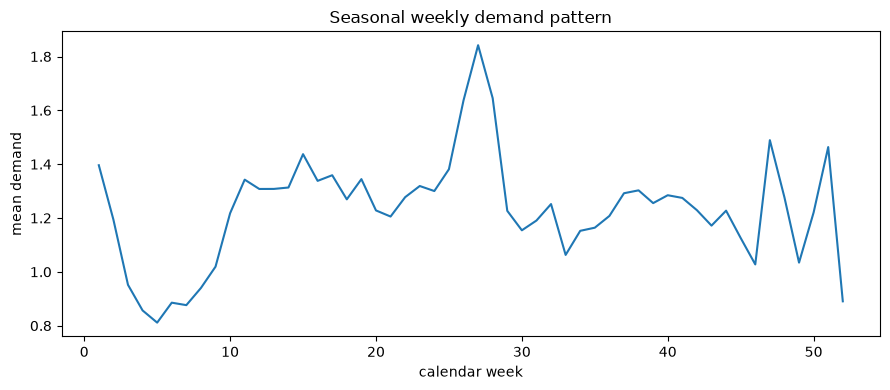

In [7]:
long=sales.melt(id_vars=[c for c in sales.columns if c not in weekly_cols],value_vars=weekly_cols,var_name='period_index',value_name='demand')
long['period_index']=pd.to_numeric(long['period_index'],errors='coerce'); long['demand']=pd.to_numeric(long['demand'],errors='coerce')
long['period_date']=long['release_date']+pd.to_timedelta(long['period_index'],unit='W'); long=long.dropna(subset=['period_date','demand']).copy()
if (DATA_DIR/'price_discount_series.csv').is_file() and {'external_code','retail'}.issubset(long.columns):
    pdx=pd.read_csv(DATA_DIR/'price_discount_series.csv')
    price_long=pdx.melt(id_vars=['external_code','retail','price'],value_vars=[c for c in weekly_cols if c in pdx.columns],var_name='period_index',value_name='discount')
    price_long['period_index']=pd.to_numeric(price_long.period_index,errors='coerce')
    long=long.merge(price_long,on=['external_code','retail','period_index'],how='left',validate='many_to_one')
    print('Exact weekly price/discount matches:',int(long.discount.notna().sum()),'of',len(long))
print('Interpretation: sales columns 0-11 are weekly lifecycle observations; period_date = release_date + period_index weeks.')
print('weekly period range:',long.period_date.min(),'to',long.period_date.max())
trend=long.groupby('period_date',as_index=False)['demand'].sum().sort_values('period_date')
weekly_pattern=long.assign(week_of_year=long.period_date.dt.isocalendar().week.astype(int)).groupby('week_of_year')['demand'].agg(['count','mean','sum'])
display(weekly_pattern.head(20))
fig,ax=plt.subplots(figsize=(11,4)); ax.plot(trend.period_date,trend.demand); ax.set(title='Weekly demand over lifecycle timestamps',xlabel='week',ylabel='demand'); fig.tight_layout(); fig.savefig(FIG_DIR/'nilakshi_visuelle_weekly_demand_over_time.png',dpi=150); plt.show()
fig,ax=plt.subplots(figsize=(9,4)); weekly_pattern['mean'].plot(ax=ax); ax.set(title='Seasonal weekly demand pattern',xlabel='calendar week',ylabel='mean demand'); fig.tight_layout(); fig.savefig(FIG_DIR/'nilakshi_visuelle_weekly_seasonality.png',dpi=150); plt.show()

## Univariate and bivariate diagnostics

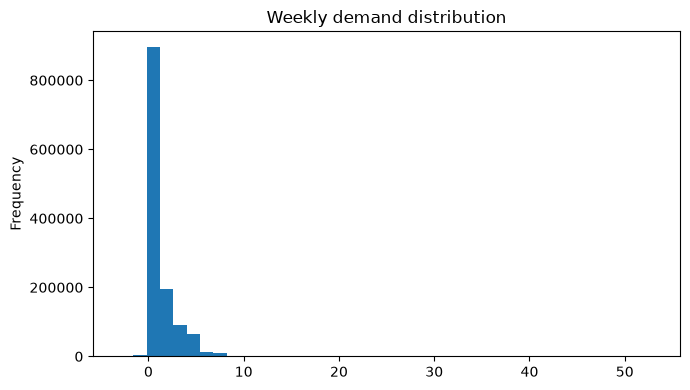

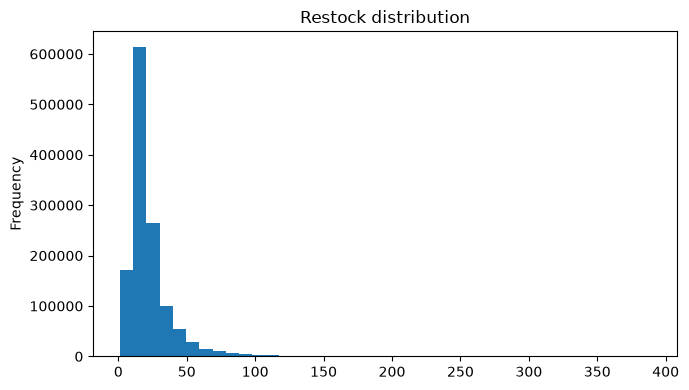

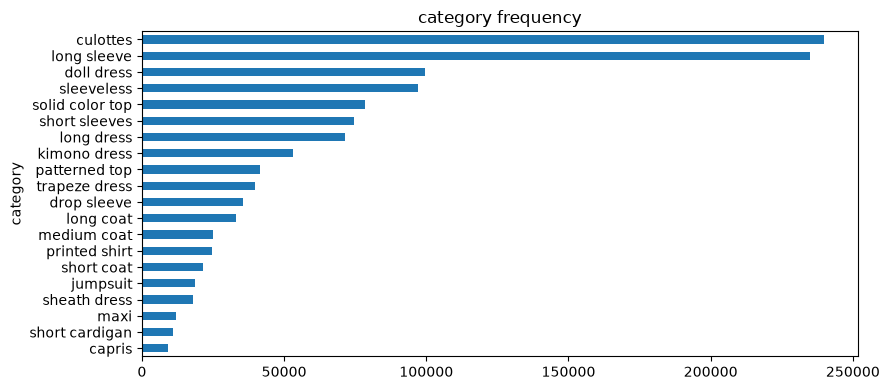

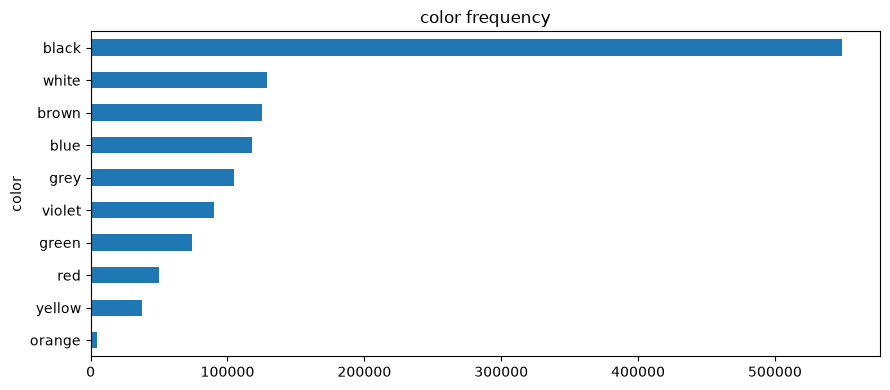

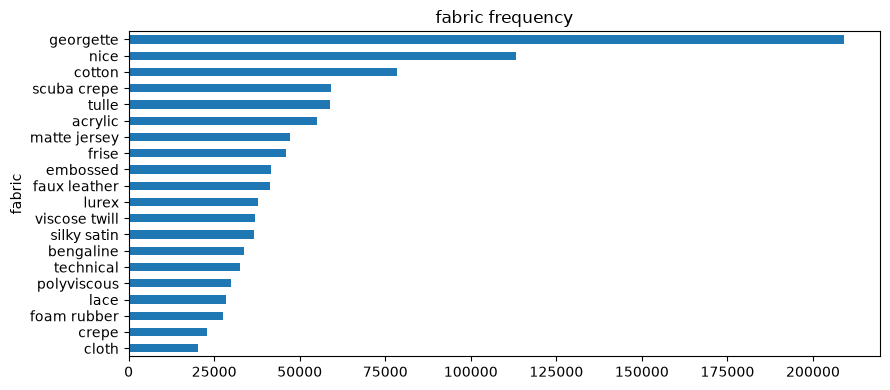

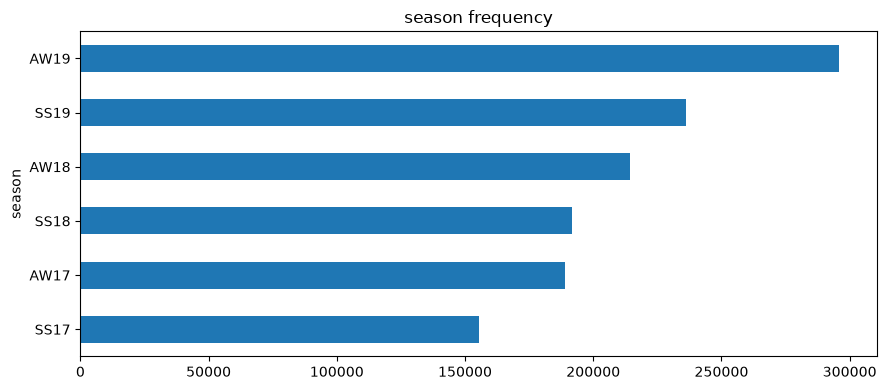

,count,mean,median,std
category,,,,
maxi,12012,1.920496,1.0,3.011247
long dress,71244,1.679552,1.0,2.274997
kimono dress,53184,1.555618,1.0,2.101014
shirt dress,5844,1.529090,1.0,2.075754
doll dress,99600,1.445723,1.0,1.833233
drop sleeve,35628,1.403447,1.0,1.761440
trapeze dress,39708,1.396973,1.0,1.737803
printed shirt,24516,1.362131,1.0,1.683370
jumpsuit,18516,1.320102,1.0,1.730347


Bivariate: restock vs demand


,restock,demand
restock,1.000000,0.517289
demand,0.517289,1.000000


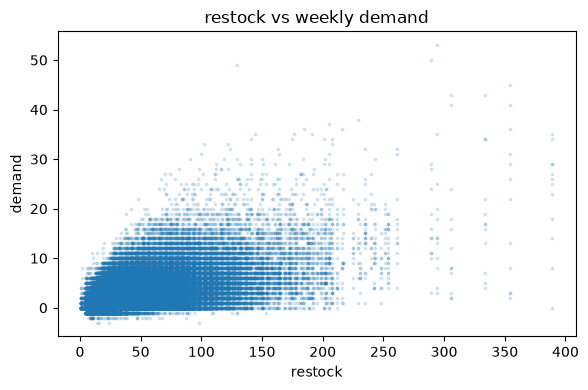

Bivariate: discount vs demand


,discount,demand
discount,1.000000,-0.005871
demand,-0.005871,1.000000


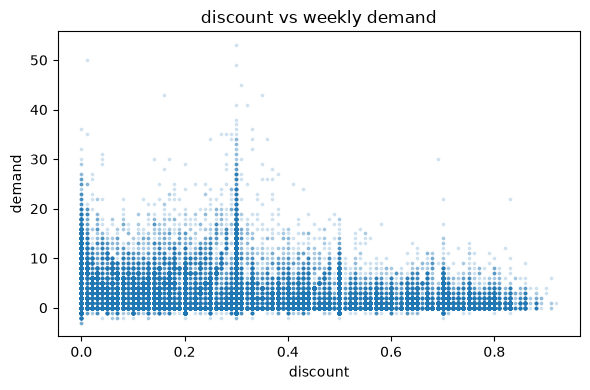

Bivariate: price vs demand


,price,demand
price,1.000000,-0.014363
demand,-0.014363,1.000000


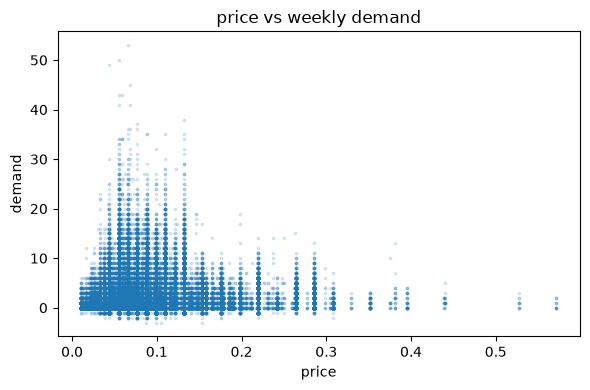

In [8]:
for col,title in [('demand','Weekly demand distribution'),('restock','Restock distribution')]:
    if col in long:
        fig,ax=plt.subplots(figsize=(7,4)); long[col].dropna().plot(kind='hist',bins=40,ax=ax); ax.set_title(title); fig.tight_layout(); fig.savefig(FIG_DIR/f'nilakshi_visuelle_{col}_distribution.png',dpi=150); plt.show()
for col in ['category','color','fabric','season']:
    if col in long:
        counts=long[col].value_counts().head(20); fig,ax=plt.subplots(figsize=(9,4)); counts.sort_values().plot.barh(ax=ax); ax.set_title(f'{col} frequency'); fig.tight_layout(); fig.savefig(FIG_DIR/f'nilakshi_visuelle_{col}_frequency.png',dpi=150); plt.show()
if 'category' in long: display(long.groupby('category')['demand'].agg(['count','mean','median','std']).sort_values('mean',ascending=False).head(20))
for x in ['restock','discount','price']:
    if x in long:
        print('Bivariate:',x,'vs demand'); display(long[[x,'demand']].corr(numeric_only=True))
        fig,ax=plt.subplots(figsize=(6,4)); ax.scatter(long[x],long.demand,s=3,alpha=.15); ax.set(xlabel=x,ylabel='demand',title=f'{x} vs weekly demand'); fig.tight_layout(); fig.savefig(FIG_DIR/f'nilakshi_visuelle_{x}_vs_demand.png',dpi=150); plt.show()

,demand,restock,price,discount,period_index,external_code,retail
demand,1.000000,5.172892e-01,-1.436280e-02,-0.005871,-1.941138e-01,-1.560984e-02,-4.283074e-02
restock,0.517289,1.000000e+00,-1.896396e-02,-0.076306,2.323581e-14,-5.499407e-02,-8.094301e-02
price,-0.014363,-1.896396e-02,1.000000e+00,0.029933,2.799763e-14,8.618841e-02,2.825780e-02
discount,-0.005871,-7.630592e-02,2.993326e-02,1.000000,4.083882e-01,4.236556e-02,1.117874e-02
period_index,-0.194114,2.323581e-14,2.799763e-14,0.408388,1.000000e+00,2.387118e-15,-3.834425e-14
external_code,-0.015610,-5.499407e-02,8.618841e-02,0.042366,2.387118e-15,1.000000e+00,2.838043e-01
retail,-0.042831,-8.094301e-02,2.825780e-02,0.011179,-3.834425e-14,2.838043e-01,1.000000e+00


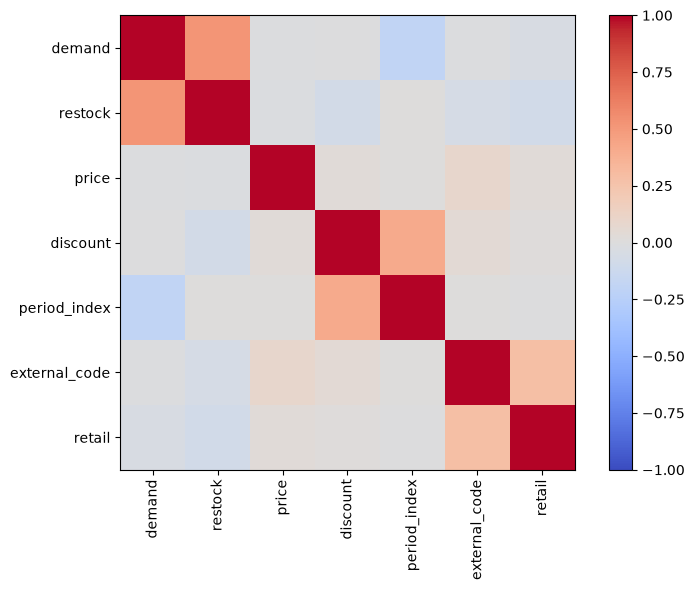

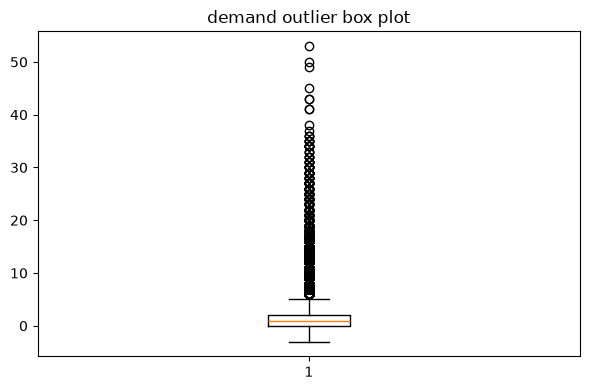

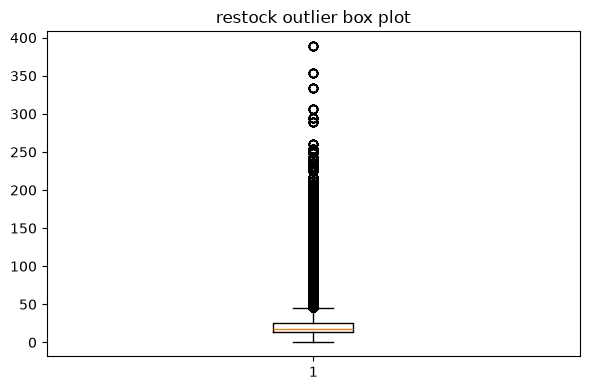

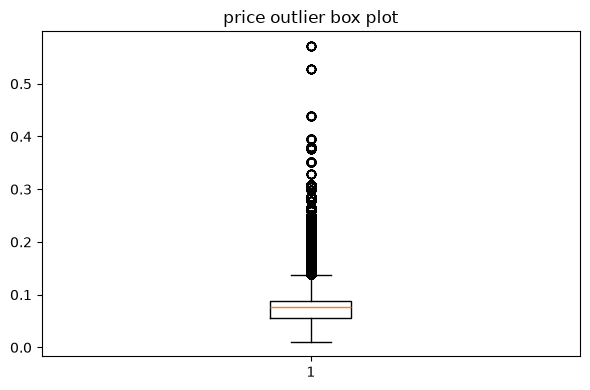

In [9]:
numeric=['demand']+[c for c in ['restock','price','discount','period_index','external_code','retail'] if c in long.columns]
if len(numeric)>1:
    corr=long[numeric].corr(); display(corr)
    fig,ax=plt.subplots(figsize=(8,6)); im=ax.imshow(corr,cmap='coolwarm',vmin=-1,vmax=1); ax.set_xticks(range(len(corr)),corr.columns,rotation=90); ax.set_yticks(range(len(corr)),corr.index); fig.colorbar(im,ax=ax); fig.tight_layout(); fig.savefig(FIG_DIR/'nilakshi_visuelle_numeric_correlation.png',dpi=150); plt.show()
for col in ['demand','restock','price']:
    if col in long:
        fig,ax=plt.subplots(figsize=(6,4)); ax.boxplot(long[col].dropna()); ax.set_title(f'{col} outlier box plot'); fig.tight_layout(); fig.savefig(FIG_DIR/f'nilakshi_visuelle_{col}_boxplot.png',dpi=150); plt.show()

## Leakage review and forecast decision

The lifecycle columns `0`–`11` in `sales.csv` are treated as **weekly** observations because the Visuelle sales lifecycle and matching price/discount series use weekly periods. A row timestamp is `release_date + period_index weeks`.

**Potentially useful pre-launch features:** product category, colour, fabric, season, release date, item/shop identifiers for grouping, and product-level price only when its timing is known before prediction. **Short-observation features:** shifted demand, shifted rolling demand, and restock/stock values already observed before the forecast timestamp. **Short-observation only / potentially unsafe:** current-row demand, future demand, post-launch aggregate restock totals, customer outcomes, and future price/discount values. No model is trained here.

In [10]:
decision={'target_column':'demand (weekly lifecycle columns '+', '.join(weekly_cols)+')','time_column':'period_date = release_date + period_index weeks','grouping_identifiers':[c for c in ['external_code','retail'] if c in sales.columns],'pre_launch_features':[c for c in ['category','color','fabric','season','release_date'] if c in long.columns],'short_observation_features':['past shifted demand/rolling demand','past observed restock only'],'unsafe_features':['current/future demand','future/post-launch restock','future price/discount','customer outcomes']}
print(json.dumps(decision,indent=2,default=str))
print('Conclusion: the real sales table supports weekly release-relative demand analysis; no model training or unexecuted metrics are claimed.')

{
  "target_column": "demand (weekly lifecycle columns 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",
  "time_column": "period_date = release_date + period_index weeks",
  "grouping_identifiers": [
    "external_code",
    "retail"
  ],
  "pre_launch_features": [
    "category",
    "color",
    "fabric",
    "season",
    "release_date"
  ],
  "short_observation_features": [
    "past shifted demand/rolling demand",
    "past observed restock only"
  ],
  "unsafe_features": [
    "current/future demand",
    "future/post-launch restock",
    "future price/discount",
    "customer outcomes"
  ]
}
Conclusion: the real sales table supports weekly release-relative demand analysis; no model training or unexecuted metrics are claimed.
